## Import Libraries and Package

In [2]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

## Load dataset

In [12]:
data_path = 'dataset/Tweets.csv'
df = pd.read_csv(data_path).dropna()
print(df.head(5))

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [13]:
# Mapping sentiment labels to numerical values
cat_id = {'negative':0, 'neutral':1, 'positive':2}
df['class'] = df['sentiment'].map(cat_id)

## Data Preprocessing

In [14]:
X = df['text'].values
y = df['class'].values
# %% train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state=123)
print(f"X train: {X_train.shape}, y train: {y_train.shape}\nX test: {X_test.shape}, y test: {y_test.shape}")

X train: (13740,), y train: (13740,)
X test: (13740,), y test: (13740,)


In [15]:
one_hot = CountVectorizer()
X_train_onehot = one_hot.fit_transform(X_train)
X_test_onehot = one_hot.transform(X_test)

In [16]:
class SentimentData(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = torch.Tensor(X.toarray())
        self.y = torch.Tensor(y).type(torch.LongTensor)
        self.len = len(self.X)
        
    def __len__(self):
        return self.len
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [17]:
train_ds = SentimentData(X= X_train_onehot, y = y_train)
test_ds = SentimentData(X_test_onehot, y_test)

In [22]:
batch_size = 512

In [24]:
train_loader = DataLoader(dataset=train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=15000)

## Model Architecture

In [25]:
class SentimentModel(nn.Module):
    def __init__(self, NUM_FEATURES, NUM_CLASSES, HIDDEN = 10):
        super().__init__()
        self.linear = nn.Linear(NUM_FEATURES, HIDDEN)
        self.linear2 = nn.Linear(HIDDEN, NUM_CLASSES)
        self.relu = nn.ReLU()
        self.log_softmax = nn.LogSoftmax(dim=1)
        
    def forward(self, x):
        x = self.linear(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.log_softmax(x)
        return x

## Hyperparameters

In [26]:
epochs = 80

model = SentimentModel(NUM_FEATURES = X_train_onehot.shape[1], NUM_CLASSES = 3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters())

## Model Training

In [27]:
train_losses = []
for e in range(epochs):
    curr_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred_log = model(X_batch)
        loss = criterion(y_pred_log, y_batch.long())
        
        curr_loss += loss.item()
        loss.backward()
        optimizer.step()
    train_losses.append(curr_loss)
    print(f"Epoch {e}, Loss: {curr_loss}")

Epoch 0, Loss: 29.308063864707947
Epoch 1, Loss: 27.845640897750854
Epoch 2, Loss: 26.100790917873383
Epoch 3, Loss: 24.189201772212982
Epoch 4, Loss: 22.242312014102936
Epoch 5, Loss: 20.39674985408783
Epoch 6, Loss: 18.7037250995636
Epoch 7, Loss: 17.191519379615784
Epoch 8, Loss: 15.857314705848694
Epoch 9, Loss: 14.684146255254745
Epoch 10, Loss: 13.64213889837265
Epoch 11, Loss: 12.731675148010254
Epoch 12, Loss: 11.914491355419159
Epoch 13, Loss: 11.205444395542145
Epoch 14, Loss: 10.555639088153839
Epoch 15, Loss: 9.96548843383789
Epoch 16, Loss: 9.433090269565582
Epoch 17, Loss: 8.952083379030228
Epoch 18, Loss: 8.518822461366653
Epoch 19, Loss: 8.113012492656708
Epoch 20, Loss: 7.741399794816971
Epoch 21, Loss: 7.390183657407761
Epoch 22, Loss: 7.079348519444466
Epoch 23, Loss: 6.782705843448639
Epoch 24, Loss: 6.507049933075905
Epoch 25, Loss: 6.248720854520798
Epoch 26, Loss: 6.01231025159359
Epoch 27, Loss: 5.7833471447229385
Epoch 28, Loss: 5.568835556507111
Epoch 29, Loss

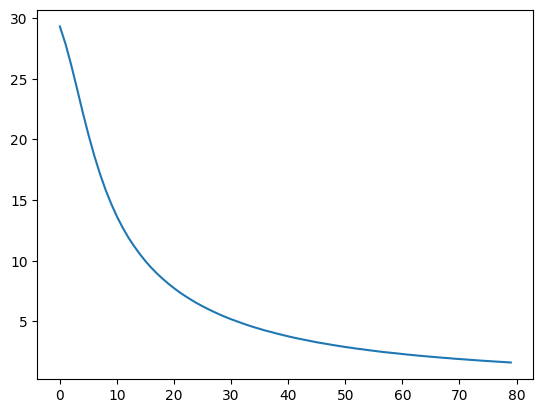

In [28]:
sns.lineplot(x=list(range(len(train_losses))), y= train_losses)
plt.show()
# %% Model Evaluation
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_test_pred_log = model(X_batch)
        y_test_pred = torch.argmax(y_test_pred_log, dim = 1)

In [29]:
y_test_pred_np = y_test_pred.squeeze().cpu().numpy()

## Validation

In [33]:
acc = accuracy_score(y_pred=y_test_pred_np, y_true = y_test)
print("The accuracy of the model is", np.round(acc, 3)*100, "%")

The accuracy of the model is 63.7 %


In [34]:
most_common_cnt = Counter(y_test).most_common()[0][1]
print(f"Naive Classifier: {np.round(most_common_cnt / len(y_test) * 100, 1)} %")

Naive Classifier: 41.0 %


<Axes: >

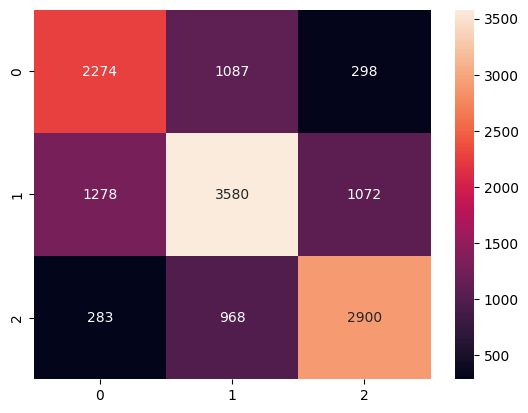

In [35]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_pred_np, y_test), annot=True, fmt=".0f")